# Manufacturing Operating Conditions Classification
## Modeling and Evaluation

This notebook develops and compares multiple machine learning classification models to predict whether manufacturing operating conditions are optimal or non-optimal based on machine and process-related variables.

# Important Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Libraries loaded successfully")

Libraries loaded successfully


# Load Dataset

In [2]:
df = pd.read_csv("Equipment dataset.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Data Preparation

In [3]:
df_model = df.drop(
    columns=[
        'UDI',
        'Product ID',
        'TWF',
        'HDF',
        'PWF',
        'OSF',
        'RNF'
    ]
)

In [4]:
df_model = pd.get_dummies(
    df_model,
    columns=['Type'],
    drop_first=True
)

In [5]:
df_model.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_L', 'Type_M'],
      dtype='object')

# Features and Target Variable

In [6]:
X = df_model.drop(columns=['Machine failure'])

y = df_model['Machine failure']

In [7]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


# Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression

Logistic Regression was used as the baseline classification model to establish an initial performance benchmark for predicting manufacturing operating conditions.

In [10]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.9675

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000


Confusion Matrix:

[[1928    4]
 [  61    7]]


## Logistic Regression Findings

The Logistic Regression model achieved high overall accuracy. However, the model struggled to identify non-optimal operating conditions, as shown by the relatively low recall for the failure class. This suggests that while the model performs well on the majority class, it may miss a significant number of failure observations.

# K-Nearest Neighbours (KNN)

KNN was included because it provides a useful comparison to Logistic Regression. KNN classifies observations based on the characteristics of similar observations within the dataset.

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, knn_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, knn_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, knn_pred))

Accuracy: 0.974

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.83      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.90      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000


Confusion Matrix:

[[1928    4]
 [  48   20]]


## KNN Findings

The KNN model improved the identification of non-optimal operating conditions compared to Logistic Regression. While overall accuracy remained similar, the model achieved higher recall and F1-score for the failure class, indicating a stronger ability to detect potential failures, overall better from a reliability perspective.

# Decision Tree

Decision Trees were evaluated because they can capture nonlinear relationships between variables and provide a more flexible classification approach than Logistic Regression.

In [12]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.978

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.66      0.67        68

    accuracy                           0.98      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:

[[1911   21]
 [  23   45]]


## Decision Tree Findings

The Decision Tree model achieved the strongest performance of the models evaluated so far, with an overall accuracy of 97.8%. This model demonstrated a significant improvement in identifying non-optimal operating conditions compared to both Logistic Regression and KNN.

The model achieved a recall of 66% for the failure class, identifying 45 of the 68 failure observations in the dataset. This represents a strong improvement over Logistic Regression, which identified only 7 failures, and KNN, which identified 20 failures.

# Random Forest

Random Forest was evaluated to determine whether combining multiple decision trees could improve prediction performance. Unlike a single Decision Tree, Random Forest builds many trees using different samples of the data and combines their predictions to make a final decision and reduces risk of overfitting especially for complex manufacturing data.

In [13]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.9815

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:

[[1927    5]
 [  32   36]]


## Random Forest Findings

The Random Forest model achieved the highest overall accuracy of all models evaluated, reaching 98.15%. The model also maintained strong accuracy for the failure class, indicating that when a failure was predicted, it was usually correct.

The model identified 36 of the 68 failure observations in the test dataset, resulting in a recall of 53% and an F1-score of 0.66 for the failure class. While the Decision Tree identified a slightly higher number of failures, the Random Forest produced fewer false positive predictions and a better balance between precision and recall.

# Model Comparison

In [14]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        0.9675,
        0.9740,
        0.9780,
        0.9815
    ],
    'Failure Recall': [
        0.10,
        0.29,
        0.66,
        0.53
    ],
    'Failure F1 Score': [
        0.18,
        0.43,
        0.67,
        0.66
    ]
})

results

,Model,Accuracy,Failure Recall,Failure F1 Score
0,Logistic Regression,0.9675,0.10,0.18
1,KNN,0.9740,0.29,0.43
2,Decision Tree,0.9780,0.66,0.67
3,Random Forest,0.9815,0.53,0.66


# Model Performance Comparison

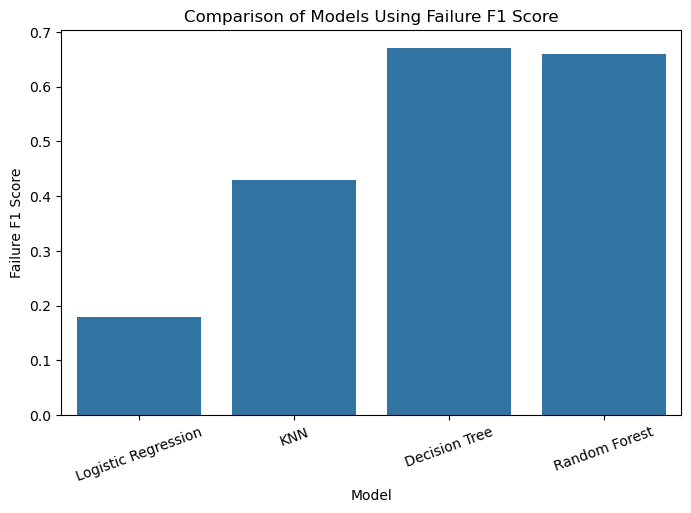

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Failure F1 Score'
)

plt.title('Comparison of Models Using Failure F1 Score')
plt.xlabel('Model')
plt.ylabel('Failure F1 Score')

plt.xticks(rotation=20)

plt.show()

## Model Comparison Findings

Four classification models were evaluated to predict non-optimal manufacturing operating conditions. While all models achieved high overall accuracy, their ability to identify failure conditions varied significantly.

The Decision Tree model achieved the highest F1-score for the failure class and the highest recall, successfully identifying 45 of the 68 failures in the test dataset. The Random Forest model achieved the highest overall accuracy, but identified fewer failures than the Decision Tree.

These results demonstrate that accuracy alone is not sufficient when evaluating models for reliability applications. From a manufacturing perspective, identifying potential failures is often more important than maximizing overall accuracy because missed failures can result in downtime, production losses, and increased maintenance costs.

# Cross-Validation

Cross-validation was used to evaluate how consistently each model performs across different subsets of the data. This helps reduce the risk of selecting a model that performs well only on a single train-test split.

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

In [17]:
cv_results = []

for name, model in models.items():

    if name in ['Logistic Regression', 'KNN']:

        scores = cross_val_score(
            model,
            scaler.fit_transform(X),
            y,
            cv=5,
            scoring='f1'
        )

    else:

        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='f1'
        )

    cv_results.append({
        'Model': name,
        'Mean F1 Score': scores.mean(),
        'Standard Deviation': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Mean F1 Score,Standard Deviation
0,Logistic Regression,0.250067,0.106565
1,KNN,0.330137,0.097621
2,Decision Tree,0.428165,0.187355
3,Random Forest,0.396944,0.182043


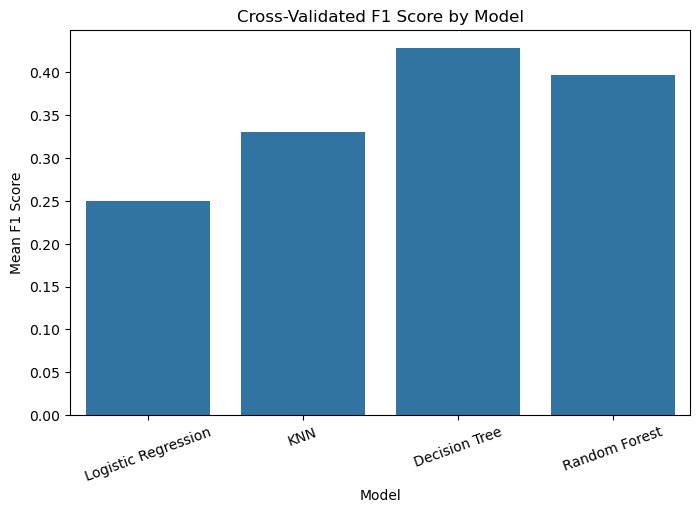

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cv_results_df,
    x='Model',
    y='Mean F1 Score'
)

plt.title('Cross-Validated F1 Score by Model')
plt.xlabel('Model')
plt.ylabel('Mean F1 Score')

plt.xticks(rotation=20)

plt.show()

## Cross-Validation Findings

The results showed that the Decision Tree model achieved the highest average F1-score, followed closely by the Random Forest model.

The ranking of the models remained consistent with the original results, providing reassurance that the findings are reliable and not the result of a single data split.

These results suggest that tree-based models are better suited for this  problem than Logistic Regression or KNN. The higher F1-scores indicate a stronger balance between identifying failures and minimizing incorrect predictions.

# Hyperparameter Tuning: KNN

In [19]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='f1'
)

knn_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", knn_grid.best_params_)

Best Parameters: {'n_neighbors': 3}


In [20]:
best_knn = knn_grid.best_estimator_

best_knn_pred = best_knn.predict(X_test_scaled)

print(classification_report(y_test, best_knn_pred))

print(confusion_matrix(y_test, best_knn_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1932
           1       0.68      0.31      0.42        68

    accuracy                           0.97      2000
   macro avg       0.83      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000

[[1922   10]
 [  47   21]]


## Tuned KNN Findings

Grid Search identified 3 nearest neighbours as the optimal parameter setting for the KNN model. While the tuned model achieved a small improvement in recall for the failure class, overall performance remained similar to the original KNN model.

The tuned KNN model identified 21 of the 68 failures in the dataset, which was an improvement over Logistic Regression but still substantially lower than the Decision Tree and Random Forest models. These results suggest that KNN may not be the most suitable approach for this manufacturing classification problem.

# Hyperparameter Tuning: Decision Tree

In [21]:
dt_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='f1'
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [22]:
best_dt = dt_grid.best_estimator_

best_dt_pred = best_dt.predict(X_test)

print(classification_report(y_test, best_dt_pred))

print(confusion_matrix(y_test, best_dt_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.84      0.69      0.76        68

    accuracy                           0.98      2000
   macro avg       0.91      0.84      0.88      2000
weighted avg       0.98      0.98      0.98      2000

[[1923    9]
 [  21   47]]


## Tuned Decision Tree Findings

Grid Search identified a maximum tree depth of 10, a minimum sample split of 5, and a minimum sample leaf size of 1 as the optimal Decision Tree parameters.

The tuned Decision Tree achieved the strongest performance of all models evaluated. The model successfully identified 47 of the 68 failure observations in the test dataset and achieved a failure-class F1-score of 0.76.

Compared to the original Decision Tree, the tuned model improved both recall and F1-score, demonstrating that hyperparameter tuning can significantly improve model performance. These results suggest that the tuned Decision Tree provides the best balance between accurately identifying failures and minimizing incorrect predictions.

From a manufacturing reliability perspective, this model would provide the greatest value because it captures a larger proportion of potential failure conditions while maintaining high overall classification performance.

# Hyperparameter Tuning: Random Forest

In [23]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1'
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [24]:
best_rf = rf_grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)

print(classification_report(y_test, best_rf_pred))

print(confusion_matrix(y_test, best_rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.59      0.70        68

    accuracy                           0.98      2000
   macro avg       0.93      0.79      0.85      2000
weighted avg       0.98      0.98      0.98      2000

[[1926    6]
 [  28   40]]


## Tuned Random Forest Findings

The tuned Random Forest achieved an F1-score of 0.70 for the failure class and successfully identified 40 of the 68 failures in the test dataset.

While the tuned Random Forest performed well and achieved high overall accuracy, it did not outperform the tuned Decision Tree. The Decision Tree achieved a higher recall and F1-score, with a stronger ability to identify non-optimal operating conditions.

The tuned Decision Tree still provides the strongest balance between identifying failures and maintaining overall predictive performance.

# Feature Importance

Feature importance was analyzed using the tuned Random Forest model to identify which machine and process-related variables had the greatest influence on predicting non-optimal operating conditions.

In [25]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
3,Torque [Nm],0.335633
2,Rotational speed [rpm],0.236831
4,Tool wear [min],0.164448
1,Process temperature [K],0.121936
0,Air temperature [K],0.120357
5,Type_L,0.011861
6,Type_M,0.008934


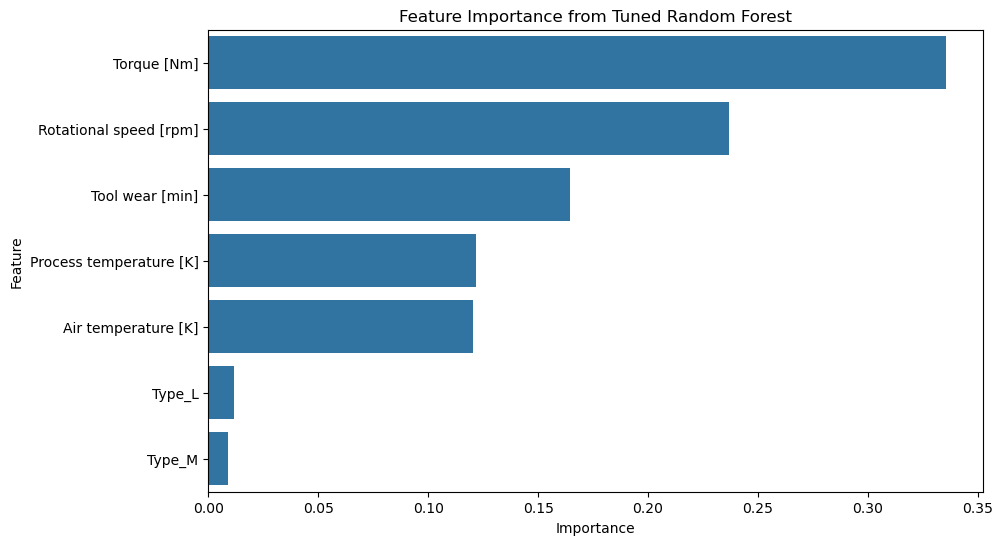

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance from Tuned Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

## Feature Importance Findings

Feature importance analysis was performed using the tuned Random Forest model to better understand which operating variables had the greatest influence on predicting non-optimal operating conditions.

The results showed that torque, rotational speed, and tool wear were the most important variables in the model. Together, these variables accounted for most of the model's predictive capability.

From a manufacturing reliability perspective, these findings are logical because excessive tool wear, abnormal torque levels, and changes in rotational speed can indicate developing equipment and existing process issues, increasing risk of failure.

Process temperature and air temperature also contributed to the model's predictions, although their influence was lower than the primary mechanical variables. Machine type had relatively little impact on prediction performance compared to the operating conditions themselves.

These findings suggest that reliability and operations teams should prioritize monitoring torque, rotational speed, and tool wear when identifying potential non-optimal operating conditions and planning maintenance activities.

# Final Conclusions

The objective of this project was to determine whether machine learning could be used to predict non-optimal manufacturing operating conditions using machine and process-related variables.

Four classification models were evaluated: Logistic Regression, K-Nearest Neighbours (KNN), Decision Tree, and Random Forest. While all models achieved high overall accuracy, their ability to identify failure conditions varied significantly.

The tuned Decision Tree model achieved the strongest overall performance, producing the highest F1-score and recall for the failure class. The model successfully identified 47 of the 68 failures in the test dataset, outperforming the other models evaluated.

The results demonstrate that machine learning can be effectively used to identify non-optimal operating conditions. In addition, the analysis showed that torque, rotational speed, and tool wear were the most influential variables in predicting machine failures.

These findings suggest that machine learning can provide valuable support for reliability, maintenance, and operations teams by helping identify developing issues before they result in equipment failures or production downtime.

# Recommendations

Based on the results of this analysis, several recommendations can be made for manufacturing and reliability teams:

1. Prioritize monitoring of torque, rotational speed, and tool wear, as these variables were identified as the strongest predictors of machine failure.

2. Consider implementing machine learning-based monitoring systems to identify non-optimal operating conditions before failures occur.

3. Use predictive insights to support proactive maintenance planning and reduce the likelihood of unplanned downtime.

4. Clean and continue to collect and store operating data to improve future model performance and support more advanced predictive maintenance initiatives.

By focusing on the variables identified in this project, organizations may be able to improve equipment reliability, decrease downtime, reduce maintenance costs, and maintain more stable production operations.

# Next Steps

This project could expand in several ways:

- Incorporate larger and more diverse manufacturing datasets.
- Explore real-time implementation of the model within manufacturing environments.
- Investigate additional operating variables and sensor data that may improve predictive performance.
- Validate the model using real-world manufacturing equipment and operating conditions.

These improvements could help further increase predictive accuracy and provide greater value for reliability and maintenance decision-making.